# Notebook 03: Inference and Testing

In this notebook, I will test my saved model weights. I want to make sure I can load the `plant_disease_model.pth` file, pass a single image through it, and get a human-readable prediction back. This is the exact logic I will later port over to my web application's backend.

In [5]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from PIL import Image
import matplotlib.pyplot as plt
import random
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Getting the class names
# I'll quickly load the dataset structure just to grab the exact class names
data_dir = '../data/raw/PlantVillage'
dummy_dataset = datasets.ImageFolder(data_dir)
class_names = dummy_dataset.classes
num_classes = len(class_names)

print(f"Loaded {num_classes} classes.")

Using device: cpu
Loaded 15 classes.


### Step 1: Rebuilding the Architecture and Loading Weights

To use the saved `.pth` file, I need to recreate the exact same ResNet18 structure I used during training, and then load the saved weights into it.

In [6]:
# Recreate the ResNet18 model
model = models.resnet18(weights=None) # We don't need pre-trained ImageNet weights anymore

# Modify the final layer to match our 16 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

# Load the saved weights
model_path = '../app/plant_disease_model.pth'
model.load_state_dict(torch.load(model_path, map_location=device))

# Set the model to evaluation mode (crucial for inference!)
model = model.to(device)
model.eval()

print("Model architecture rebuilt and trained weights loaded successfully.")

Model architecture rebuilt and trained weights loaded successfully.


### Step 2: Making a Prediction

Now I will write a function that takes an image path, applies the same validation transformations I used during training, and outputs the predicted disease.

Testing on: Pepper__bell___Bacterial_spot / 447735c7-b650-4ef6-a53b-8fb661470de3___JR_B.Spot 3370.JPG


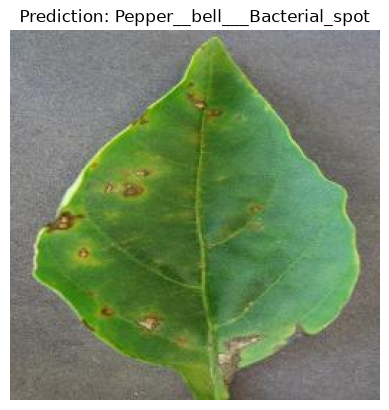

In [7]:
# The exact same transforms used for validation in Notebook 01
inference_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_image(image_path):
    # Open the image
    image = Image.open(image_path).convert('RGB')
    
    # Apply transforms and add a batch dimension (models expect batches)
    input_tensor = inference_transforms(image).unsqueeze(0).to(device)
    
    # Make the prediction
    with torch.no_grad():
        outputs = model(input_tensor)
        # Get the highest probability class
        _, predicted_idx = torch.max(outputs, 1)
        
    predicted_class = class_names[predicted_idx.item()]
    
    # Display the result
    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class}")
    plt.axis('off')
    plt.show()

# Let's test it on a random image from our dataset!
# I'll pick a random class folder, then a random image inside it
random_class = random.choice(class_names)
class_path = os.path.join(data_dir, random_class)
random_image_file = random.choice(os.listdir(class_path))
test_image_path = os.path.join(class_path, random_image_file)

print(f"Testing on: {random_class} / {random_image_file}")
predict_image(test_image_path)